## Goal

Understand the Recommendation Problem, the available data, and the type of feedback before selecting any recommendation algorithm.

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
users_df = pd.read_csv('../data/raw/users.dat', sep='::', engine='python', header=None, names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'])
ratings_df = pd.read_csv('../data/raw/ratings.dat', sep='::', engine='python', header=None, names=['UserID', 'MovieID', 'Rating', 'Timestamp'])
movies_df = pd.read_csv('../data/raw/movies.dat', sep='::', engine='python', header=None, names=['MovieID', 'Title', 'Genres'], encoding='latin-1')

In [3]:
# Shapes
for idx, item in enumerate([users_df, ratings_df, movies_df]):
    print(f'item {idx + 1}: {item.shape}')
    print(20*'=')

item 1: (6040, 5)
item 2: (1000209, 4)
item 3: (3883, 3)


In [4]:
# Checking the statistics of DataFrames

In [5]:
# users_df
users_df.head(), users_df.sample(10)

(   UserID Gender  Age  Occupation Zip-code
 0       1      F    1          10    48067
 1       2      M   56          16    70072
 2       3      M   25          15    55117
 3       4      M   45           7    02460
 4       5      M   25          20    55455,
       UserID Gender  Age  Occupation Zip-code
 1332    1333      M   25          17    06460
 1892    1893      F   35           0    90024
 706      707      M   35           7    17740
 4650    4651      F   45           0    10036
 2712    2713      M   25           7    96811
 4279    4280      M   35          17    27587
 2453    2454      M   18           0    97005
 970      971      M   25          12    43615
 1530    1531      M   45          17    60462
 3621    3622      M   18           1    02446)

In [6]:
# ratings_df
ratings_df.head(), ratings_df.sample(10)

(   UserID  MovieID  Rating  Timestamp
 0       1     1193       5  978300760
 1       1      661       3  978302109
 2       1      914       3  978301968
 3       1     3408       4  978300275
 4       1     2355       5  978824291,
         UserID  MovieID  Rating  Timestamp
 232042    1407     3713       5  974764310
 799457    4790     2314       4  970350855
 642167    3861     3177       3  965857088
 647041    3894     1188       4  965791162
 640231    3847     1246       3  965884383
 431588    2629     2478       3  973628798
 828301    4977     1625       5  962601075
 857071    5151        2       3  961985985
 360454    2106     1453       1  975440968
 763838    4543     3423       4  964671226)

In [7]:
# movies_df
movies_df.head(), movies_df.sample(10)

(   MovieID                               Title                        Genres
 0        1                    Toy Story (1995)   Animation|Children's|Comedy
 1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
 2        3             Grumpier Old Men (1995)                Comedy|Romance
 3        4            Waiting to Exhale (1995)                  Comedy|Drama
 4        5  Father of the Bride Part II (1995)                        Comedy,
       MovieID                                        Title  \
 2530     2599                              Election (1999)   
 1016     1029                                 Dumbo (1941)   
 1479     1514             Temptress Moon (Feng Yue) (1996)   
 490       494                    Executive Decision (1996)   
 2503     2572            10 Things I Hate About You (1999)   
 2306     2375                        Money Pit, The (1986)   
 2309     2378                        Police Academy (1984)   
 2104     2173   Navigator:

In [8]:
# DFs' info & Description and Checking for NaN and duplicated values
df_list = [users_df, ratings_df, movies_df]
for df in df_list:
    print(df.info())
    print(40*'+')
    print(df.describe())
    print(40*'+')
    print(df.isna().sum())
    print(40*'+')
    print(df.duplicated().sum())
    print(40*'=')

<class 'pandas.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   UserID      6040 non-null   int64
 1   Gender      6040 non-null   str  
 2   Age         6040 non-null   int64
 3   Occupation  6040 non-null   int64
 4   Zip-code    6040 non-null   str  
dtypes: int64(3), str(2)
memory usage: 236.1 KB
None
++++++++++++++++++++++++++++++++++++++++
            UserID          Age   Occupation
count  6040.000000  6040.000000  6040.000000
mean   3020.500000    30.639238     8.146854
std    1743.742145    12.895962     6.329511
min       1.000000     1.000000     0.000000
25%    1510.750000    25.000000     3.000000
50%    3020.500000    25.000000     7.000000
75%    4530.250000    35.000000    14.000000
max    6040.000000    56.000000    20.000000
++++++++++++++++++++++++++++++++++++++++
UserID        0
Gender        0
Age           0
Occupation    0
Zip-code      0
dtype: int64

In [9]:
# Column Names
for df in df_list:
    print(df.columns)
    print(40*'=')

Index(['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'], dtype='str')
Index(['UserID', 'MovieID', 'Rating', 'Timestamp'], dtype='str')
Index(['MovieID', 'Title', 'Genres'], dtype='str')


In [10]:
# User, Item and Interactions' count
user_count = users_df.shape[0]
item_count = movies_df.shape[0]
interaction_count = ratings_df.shape[0]
print(user_count, item_count, interaction_count, sep='\n')

6040
3883
1000209


In [11]:
# Sparse or Dense
print(interaction_count / (user_count * item_count))

0.04264679797998748


In [12]:
# Rating Distribution
rating_distribution = ratings_df['Rating'].value_counts(normalize=True) * 100
rating_distribution

Rating
4    34.889808
3    26.114242
5    22.626271
2    10.753453
1     5.616226
Name: proportion, dtype: float64

In [13]:
# User Activity Distribution
user_activity_distribution = ratings_df.groupby('UserID')['Rating'].size()
user_activity_distribution

UserID
1        53
2       129
3        51
4        21
5       198
       ... 
6036    888
6037    202
6038     20
6039    123
6040    341
Name: Rating, Length: 6040, dtype: int64

In [14]:
# Movie Popularity Distribution
movie_interaction_count = ratings_df.groupby('MovieID')['Rating'].size()
movie_interaction_count

MovieID
1       2077
2        701
3        478
4        170
5        296
        ... 
3948     862
3949     304
3950      54
3951      40
3952     388
Name: Rating, Length: 3706, dtype: int64

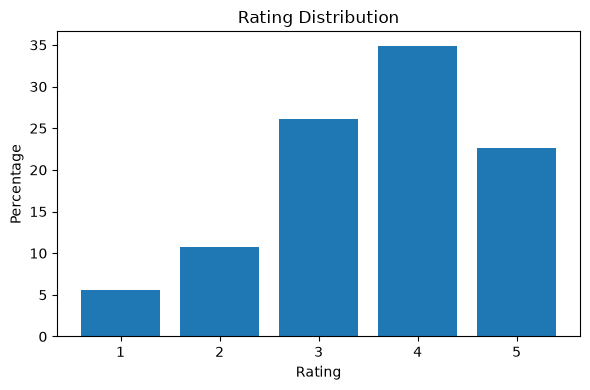

In [29]:
# Visualization
# Rating Distribution
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(rating_distribution.index, rating_distribution.values)
ax.set_title('Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Percentage')

fig.tight_layout()
fig.savefig('../figures/Sprint01/rating_distribution.png', dpi=300)
plt.show()
plt.close(fig)

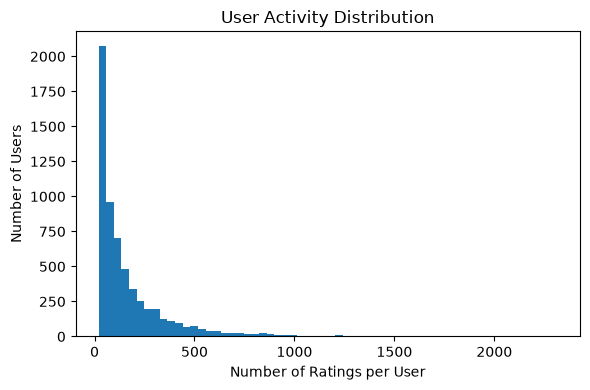

In [30]:
# User Activity Distribution
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(user_activity_distribution, bins=60)
ax.set_title('User Activity Distribution')
ax.set_xlabel('Number of Ratings per User')
ax.set_ylabel('Number of Users')

fig.tight_layout()
fig.savefig('../figures/Sprint01/user_activity_distribution.png', dpi=300)
plt.show()
plt.close(fig)

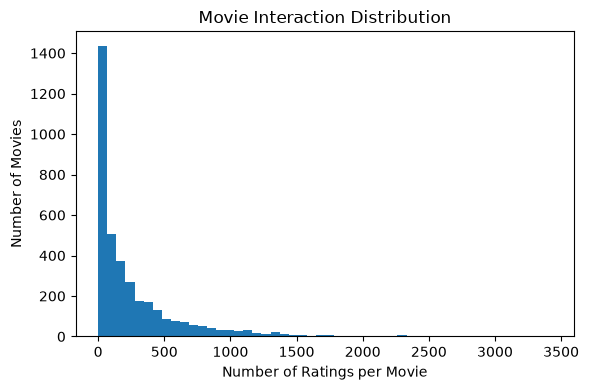

In [31]:
# Movie Interaction Distribution
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(movie_interaction_count, bins=50)
ax.set_title('Movie Interaction Distribution')
ax.set_xlabel('Number of Ratings per Movie')
ax.set_ylabel('Number of Movies')

fig.tight_layout()
fig.savefig('../figures/Sprint01/movie_interaction_distribution.png', dpi=300)
plt.show()
plt.close(fig)

In [ ]:
# Temporal Analysis

In [34]:
ratings_df['Timestamp'].min()

np.int64(956703932)

In [35]:
ratings_df['Timestamp'].max()

np.int64(1046454590)

In [36]:
ratings_df['TimestampDate'] = pd.to_datetime(ratings_df['Timestamp'], unit='s')

In [38]:
ratings_df['TimestampDate'].min()

Timestamp('2000-04-25 23:05:32')

In [39]:
ratings_df['TimestampDate'].max()

Timestamp('2003-02-28 17:49:50')

In [44]:
ratings_df['YearMonth'] = ratings_df['TimestampDate'].dt.to_period('M')

In [49]:
ratings_per_month = ratings_df.groupby('YearMonth')['Rating'].size()

In [50]:
ratings_per_month.head()

YearMonth
2000-04     11396
2000-05     67437
2000-06     54486
2000-07     90334
2000-08    182109
Freq: M, Name: Rating, dtype: int64

In [51]:
ratings_per_month.tail()

YearMonth
2002-10    1014
2002-11    1908
2002-12    1264
2003-01    1852
2003-02    1496
Freq: M, Name: Rating, dtype: int64

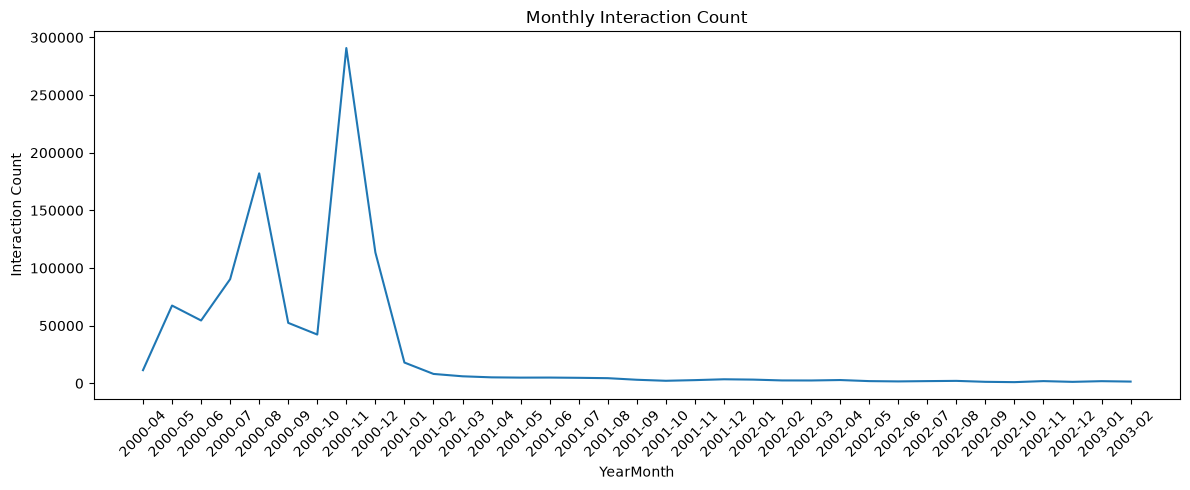

In [61]:
# Visualization
plt.figure(figsize=(12, 5))
plt.plot(ratings_per_month.index.astype('str'), ratings_per_month.values)
plt.title('Monthly Interaction Count')
plt.xticks(rotation=45)
plt.xlabel('YearMonth')
plt.ylabel('Interaction Count')
plt.tight_layout()
plt.savefig('../figures/Sprint01/monthly_interaction_count.png', dpi=300)
plt.show()

Interaction activity peaked sharply around October 2000 and then declined substantially.

The dataset contains substantially more interactions during the earlier period, followed by a long period of much lower activity.

## Engineering Analysis

The initial analysis revealed several characteristics that may influence the design of the recommendation system:

User activity is highly uneven.
Movie popularity is highly uneven.
Ratings are concentrated toward higher values.
Interaction volume changes considerably over time.
The dataset is sparse, with only a small fraction of possible user-movie interactions being observed.

These characteristics should be considered during later stages of the project, particularly when designing the recommendation approach, evaluation strategy, and validation procedure.

## Engineering Decisions

### 1. Monthly Temporal Aggregation

**Decision:**  
Use monthly aggregation for temporal analysis.

**Why:**  
Monthly aggregation provides a balanced level of temporal detail. Daily aggregation would introduce more noise, while yearly aggregation would hide important temporal patterns.

**Alternative:**  
Quarterly aggregation.

---

### 2. Movie Dataset Encoding

**Decision:**  
Use `latin-1` encoding when loading `movies.dat`.

**Why:**  
The movie titles contain characters outside the standard English character set. Using `latin-1` allowed the dataset to be loaded successfully without the Unicode decoding error encountered with UTF-8.

**Alternative:**  
Another compatible character encoding identified through further investigation.

---

### 3. Loading Headerless Raw Files

**Decision:**  
Use `header=None` and explicitly provide column names.

**Why:**  
The raw `.dat` files do not contain column headers. Therefore, pandas must be informed that no header exists, while the column names are provided explicitly based on the dataset documentation.

**Alternative:**  
Preprocess the raw files and add column names before loading them.

---

### 4. Interaction Counting with `size()`

**Decision:**  
Use `size()` to count interaction records within groups.

**Why:**  
`size()` counts rows within each group, including rows containing missing values. At this stage, potentially informative records should not be implicitly excluded before completing the data-quality investigation.

**Alternative:**  
Use `count()`, which excludes missing values from the count of the selected column.

---

### 5. Rating Distribution Visualization

**Decision:**  
Use a bar plot for the rating distribution.

**Why:**  
Ratings are discrete values. A bar plot makes it straightforward to compare the frequency of each rating value.

**Alternative:**  
Pie chart.

---

### 6. User and Movie Activity Visualization

**Decision:**  
Use histograms to analyze user activity and movie interaction counts.

**Why:**  
The activity counts contain many distinct numerical values. Histograms help reveal their range, concentration, and strongly right-skewed distributions.

**Alternative:**  
Box plot.

---

### 7. Temporal Interaction Visualization

**Decision:**  
Use a line plot for monthly interaction volume.

**Why:**  
Time is ordered and the monthly observations form a temporal sequence. A line plot makes changes, peaks, and declines over time easier to observe.

**Alternative:**  
Histogram or box plot.

## Key Findings

### Dataset Structure
- The dataset consists of three main entities: Users, Movies, and Ratings/Interactions.
- The User dataset contains 6,040 users and 5 features.
- The Ratings dataset contains more than one million interaction records.
- The Movie dataset contains 3,883 movies and 3 features.
- UserID and MovieID were treated primarily as identifiers rather than meaningful predictive features.
- User-related attributes such as Age, Gender, and Occupation provide additional information about users, while movie-related attributes such as Genres provide information about items.

### Rating Distribution
- Ratings are concentrated toward higher values.
- Rating 4 has the highest frequency, followed by Ratings 3 and 5.
- Lower ratings occur less frequently in comparison with higher ratings.
- Therefore, the rating distribution is not uniform and shows a tendency toward higher ratings.
  
### User Activity Distribution
- User activity is highly uneven across the dataset.
- Most users have a relatively small number of interactions.
- A smaller number of users have a substantially larger number of interactions.
- This indicates a highly right-skewed user activity distribution.

### Movie Popularity Distribution
- Movie interactions are also highly uneven.
- Most movies receive relatively few ratings, while a small number of movies receive a very large number of ratings.
- This indicates a strong imbalance in item popularity and suggests the presence of a long-tail pattern.

### Timestamp Analysis
- The interaction timestamps are represented as Unix timestamps in seconds.
- The timestamps were converted into a datetime representation to make temporal analysis easier.
- The dataset covers a period of approximately three years.
- Monthly aggregation was selected for temporal analysis because daily aggregation would produce a highly detailed and potentially noisy view, while yearly aggregation would provide too little temporal detail.

### Temporal Interaction Patterns
- The number of interactions varies substantially over time.
- A pronounced peak in interaction activity can be observed around late 2000.
- After this peak, the overall interaction volume decreases considerably and remains at a much lower level during the later period.
- This temporal pattern should be considered when designing the evaluation strategy for the recommendation system.

## Sprint Retrospective

This sprint helped me better understand the dataset before moving toward recommendation modeling.

One of the main things I learned was how to inspect the structure and data types of different datasets and determine which columns provide meaningful information for the recommendation problem.

I also learned how different visualizations can be selected based on the type of information that needs to be analyzed. For example, a bar plot was useful for examining the distribution of discrete rating values, while histograms were more appropriate for analyzing user activity and movie interaction counts. A line plot was more suitable for analyzing interaction volume over time.

Another important part of the sprint was working with timestamps. I initially had difficulty converting the Unix timestamps into a monthly representation for temporal analysis. After researching the relevant pandas functionality and understanding the required parameters, I was able to perform the transformation and aggregate the interactions by month.

The sprint also helped me become more comfortable with identifying patterns such as skewed distributions, uneven user activity, and uneven movie popularity.

I believe I performed better in the visualization part compared with previous projects, especially when selecting an appropriate visualization for the temporal interaction analysis.

For future work, I want to improve my ability to identify useful patterns from dataset features and make appropriate visualization and engineering decisions more independently.